In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
debrecen_data = {
    'NMAE': {'PREC': {'AIFS': 0.3575826774, 'IFS': 0.3414186971}, 'TEMP': {'AIFS': 0.505713905, 'IFS': 0.580362162},  'DEWP': {'AIFS': 0.453268685, 'IFS': 0.60497602}, 'MSLP': {'AIFS': 0.426277755, 'IFS': 0.29241951}, 'WIND': {'AIFS': 0.742482239, 'IFS': 0.658976276}},
    'NRMSE': {'PREC': {'AIFS': 0.6354030427, 'IFS': 0.7000359307}, 'TEMP': {'AIFS': 0.64888005, 'IFS': 0.739557598},  'DEWP': {'AIFS': 0.590975367, 'IFS': 0.740015933}, 'MSLP': {'AIFS': 0.563000004, 'IFS': 0.427113098}, 'WIND': {'AIFS': 0.983508851, 'IFS': 0.925925358}},
    'PEARSONR': {'TEMP': {'AIFS': 0.851113, 'IFS': 0.825186}, 'DEWP': {'AIFS': 0.823246682, 'IFS': 0.79161787}, 'MSLP': {'AIFS': 0.860183, 'IFS': 0.91052}, 'WIND': {'AIFS': 0.350749, 'IFS': 0.468034}},
}

josvafo_data = {
    'NMAE': {'PREC': {'AIFS': 0.3380072280, 'IFS': 0.2473439021}, 'TEMP': {'AIFS': 0.451935914, 'IFS': 0.544118613}, 'DEWP': {'AIFS': 0.53980797, 'IFS': 0.71227349}, 'MSLP': {'AIFS': 0.426281633, 'IFS': 0.324052218}, 'WIND': {'AIFS': 1.329855968, 'IFS': 1.280362108}},
    'NRMSE': {'PREC': {'AIFS': 0.7134093230, 'IFS': 0.6219145700}, 'TEMP': {'AIFS': 0.562942693, 'IFS': 0.718729408},  'DEWP': {'AIFS': 0.666996657, 'IFS': 0.904739749}, 'MSLP': {'AIFS': 0.552761638, 'IFS': 0.449402627}, 'WIND': {'AIFS': 1.766148971, 'IFS': 1.593482407}},
    'PEARSONR': {'TEMP': {'AIFS': 0.836197, 'IFS': 0.776361}, 'DEWP': {'AIFS': 0.819374033, 'IFS': 0.755987184}, 'MSLP': {'AIFS': 0.864752, 'IFS': 0.896197}, 'WIND': {'AIFS': 0.177294, 'IFS': 0.375495}},
}

siofok_data = {
    'NMAE': {'PREC': {'AIFS': 0.338007228, 'IFS': 0.247343902}, 'TEMP': {'AIFS': 0.541902123, 'IFS': 0.606511507}, 'DEWP': {'AIFS': 0.744155118, 'IFS': 0.545223106}, 'MSLP': {'AIFS': 0.379124112, 'IFS': 0.336290007}, 'WIND': {'AIFS': 0.811399764, 'IFS': 0.677654317}},
    'NRMSE': {'PREC': {'AIFS': 0.713409323, 'IFS': 0.621914570}, 'TEMP': {'AIFS': 0.667026852, 'IFS': 0.746719101},  'DEWP': {'AIFS': 0.897863253, 'IFS': 0.697893233}, 'MSLP': {'AIFS': 0.526495239, 'IFS': 0.462574459}, 'WIND': {'AIFS': 1.168464044, 'IFS': 0.882871256}},
    'PEARSONR': {'TEMP': {'AIFS': 0.755754, 'IFS': 0.787682},  'DEWP': {'AIFS': 0.689767229, 'IFS': 0.751477922}, 'MSLP': {'AIFS': 0.875056, 'IFS': 0.893021}, 'WIND': {'AIFS': 0.055528, 'IFS': 0.487144}},
}

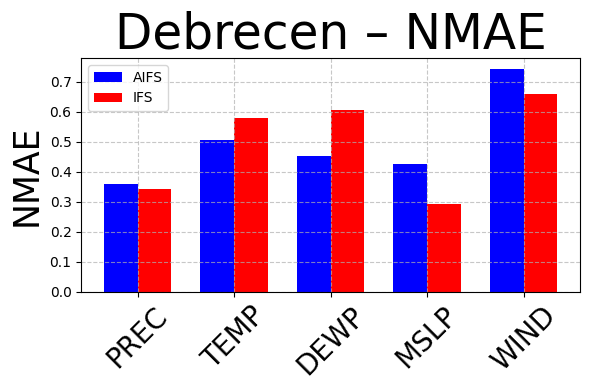

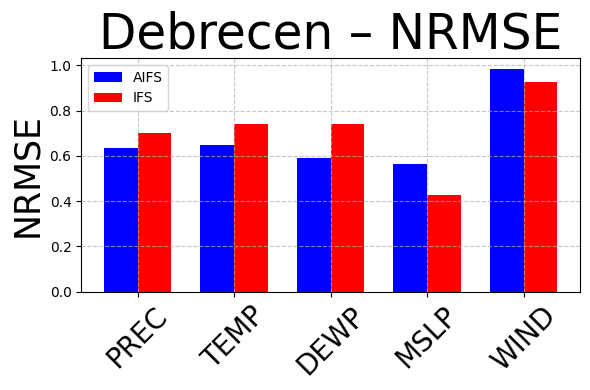

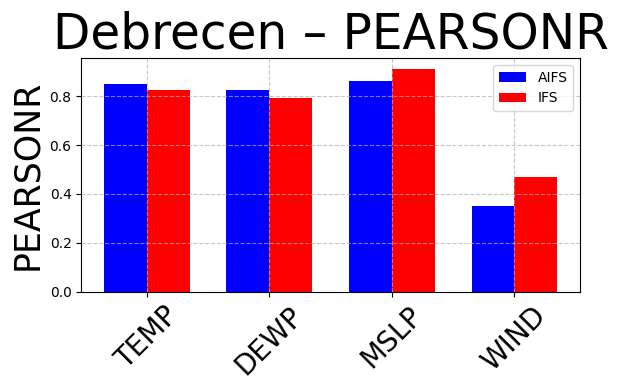

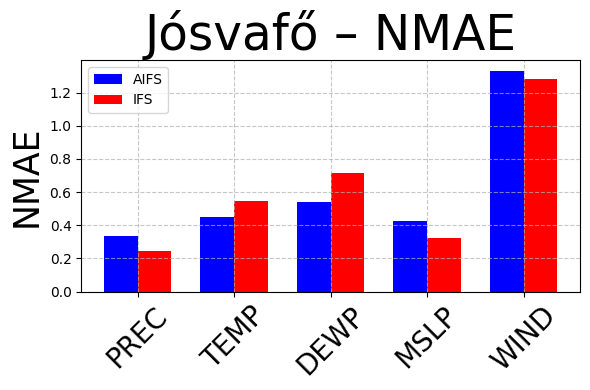

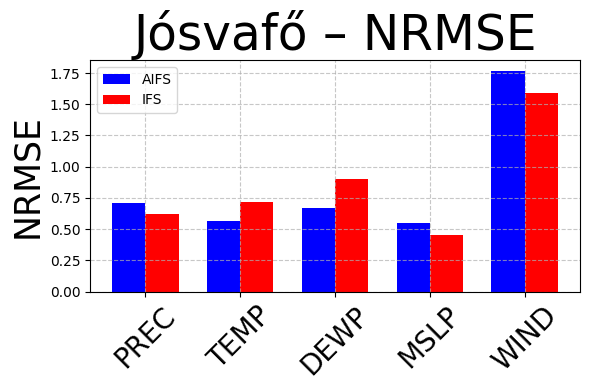

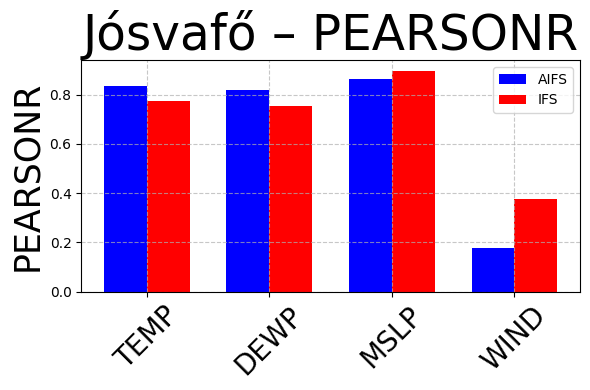

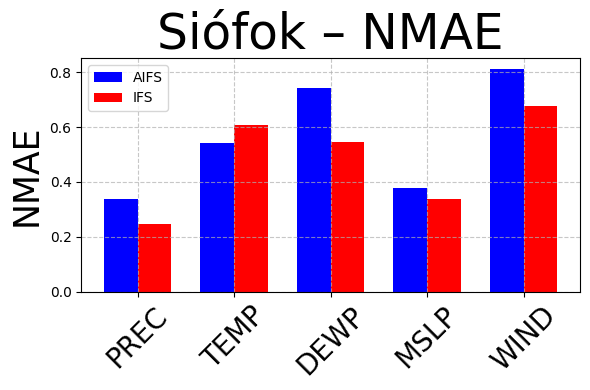

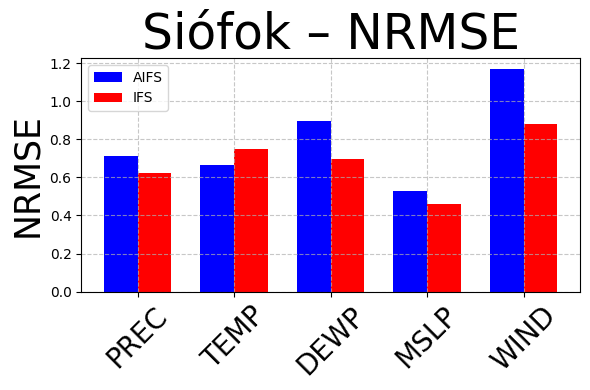

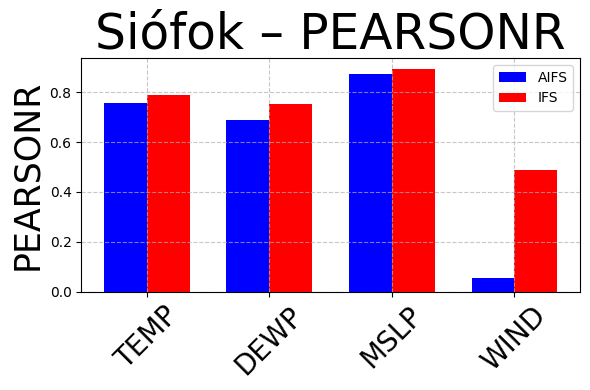

In [16]:
cities = {
    "Debrecen": debrecen_data,
    "Jósvafő": josvafo_data,
    "Siófok": siofok_data
}

metrics = ["NMAE", "NRMSE", "PEARSONR"]
full_order = ["PREC", "TEMP", "DEWP", "MSLP", "WIND"]
pearson_order = ["TEMP", "DEWP", "MSLP", "WIND"]

for city_name, city_data in cities.items():
    for metric in metrics:
        plt.figure(figsize=(6,4))

        # fix sorrend
        if metric == "PEARSONR":
            params = [p for p in pearson_order if p in city_data[metric]]
        else:
            params = [p for p in full_order if p in city_data[metric]]

        x = np.arange(len(params))
        width = 0.35

        aifs_vals = [city_data[metric][p]["AIFS"] for p in params]
        ifs_vals = [city_data[metric][p]["IFS"] for p in params]

        plt.bar(x - width/2, aifs_vals, width=width, color='blue', label='AIFS')
        plt.bar(x + width/2, ifs_vals, width=width, color='red', label='IFS')

        plt.xticks(x, params, fontsize=20, rotation=45)
        plt.ylabel(metric, fontsize=25)
        plt.title(f"{city_name} – {metric}", fontsize=35)
        plt.legend()
        plt.tight_layout()
        plt.grid(alpha=0.7, linestyle='--', zorder=-1)
        plt.show()
